# Project 3 – DBSCAN

V tomto projektu implementujeme algoritmus **DBSCAN** přesně podle zadaného pseudokódu a vyzkoušíme ho na datasetu Titanic.


In [45]:
import numpy as np
import pandas as pd
from math import sqrt
from time import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN as SklearnDBSCAN


## Vlastní implementace DBSCAN podle pseudokódu

Níže je implementace funkce `find_neighbors` a `dbscan`, která co nejvěrněji kopíruje zadaný pseudokód (bez optimalizací).


In [46]:
UNCLASSIFIED = 0
NOISE = -1
CORE = 1
BORDER = 2

def euclidean_distance(point_a, point_b):
    distance_sum = 0.0
    for i in range(len(point_a)):
        difference = point_a[i] - point_b[i]
        distance_sum = distance_sum + difference * difference
    return sqrt(distance_sum)

def find_neighbors(dataset, point_index, eps):
    neighbor_indices = []
    point_p = dataset[point_index]
    for q_index in range(len(dataset)):
        point_q = dataset[q_index]
        distance = euclidean_distance(point_p, point_q)
        if distance <= eps:
            neighbor_indices.append(q_index)
    return neighbor_indices

def dbscan(dataset, eps, min_pts):
    num_points = len(dataset)
    labels = [UNCLASSIFIED for _ in range(num_points)]
    point_types = [UNCLASSIFIED for _ in range(num_points)]

    cluster_id = 0

    for p_index in range(num_points):
        if labels[p_index] == UNCLASSIFIED:
            neighbor_pts = find_neighbors(dataset, p_index, eps)
            if len(neighbor_pts) < min_pts:
                labels[p_index] = NOISE
                point_types[p_index] = NOISE
                continue

            cluster_id = cluster_id + 1

            labels[p_index] = cluster_id
            point_types[p_index] = CORE

            i = 0
            while i < len(neighbor_pts):
                p_prime_index = neighbor_pts[i]

                if labels[p_prime_index] == NOISE:
                    point_types[p_prime_index] = BORDER
                    labels[p_prime_index] = cluster_id

                if labels[p_prime_index] == UNCLASSIFIED:
                    labels[p_prime_index] = cluster_id

                    neighbor_pts_prime = find_neighbors(dataset, p_prime_index, eps)
                    if len(neighbor_pts_prime) >= min_pts:
                        point_types[p_prime_index] = CORE
                        for neighbor_index in neighbor_pts_prime:
                            if neighbor_index not in neighbor_pts:
                                neighbor_pts.append(neighbor_index)
                    else:
                        point_types[p_prime_index] = BORDER

                i = i + 1

    return np.array(labels), np.array(point_types)


## Načtení a příprava datasetu `clusters3.csv`

Dataset obsahuje dvourozměrné body (`x`, `y`), na kterých je chování DBSCAN dobře vidět v rovině.


In [47]:
clusters_path = "clusters3.csv"
clusters_df = pd.read_csv(clusters_path, sep=";")

clusters_data = clusters_df[["x", "y"]].values.astype(float)

print("Počet vzorků:", clusters_data.shape[0])
print("Prvních pár bodů:")
print(clusters_df.head())


Počet vzorků: 300
Prvních pár bodů:
          x          y
0 -8.904622   9.340533
1 -8.854129  10.615803
2 -8.750245  10.174964
3 -7.242460   9.180114
4 -7.314041   7.264030


## Vlastní implementace DBSCAN na `clusters3.csv`


In [48]:
eps = 0.5
min_pts = 5

start_time = time()
labels_custom_raw, point_types = dbscan(clusters_data, eps=eps, min_pts=min_pts)
elapsed_custom = time() - start_time

# přečíslování clusterů na 0, 1, 2, ... (šum -1 necháme)
labels_custom = labels_custom_raw.copy()
unique_labels_custom_raw = sorted(set(labels_custom_raw))
cluster_labels_custom = [label for label in unique_labels_custom_raw if label != NOISE]
mapping_custom = {old: new for new, old in enumerate(cluster_labels_custom)}
for old_label, new_label in mapping_custom.items():
    labels_custom[labels_custom_raw == old_label] = new_label

unique_labels_custom = set(labels_custom)
n_clusters_custom = len(unique_labels_custom) - (1 if NOISE in unique_labels_custom else 0)
n_noise_custom = np.sum(labels_custom == NOISE)

print("Vlastní DBSCAN na clusters3.csv")
print("Počet clusterů (bez šumu):", n_clusters_custom)
print("Počet bodů označených jako šum:", n_noise_custom)
print("Čas běhu [s]:", elapsed_custom)


Vlastní DBSCAN na clusters3.csv
Počet clusterů (bez šumu): 10
Počet bodů označených jako šum: 127
Čas běhu [s]: 0.04792499542236328


## Porovnání se `sklearn.DBSCAN` na stejném datasetu


In [49]:
start_time = time()
sk_dbscan = SklearnDBSCAN(eps=eps, min_samples=min_pts, metric="euclidean")
labels_sklearn_raw = sk_dbscan.fit_predict(clusters_data)

# přečíslování clusterů na 0, 1, 2, ... (šum -1 necháme)
labels_sklearn = labels_sklearn_raw.copy()
unique_labels_sklearn_raw = sorted(set(labels_sklearn_raw))
cluster_labels_sklearn = [label for label in unique_labels_sklearn_raw if label != -1]
mapping_sklearn = {old: new for new, old in enumerate(cluster_labels_sklearn)}
for old_label, new_label in mapping_sklearn.items():
    labels_sklearn[labels_sklearn_raw == old_label] = new_label

elapsed_sklearn = time() - start_time

unique_labels_sklearn = set(labels_sklearn)
n_clusters_sklearn = len(unique_labels_sklearn) - (1 if -1 in unique_labels_sklearn else 0)
n_noise_sklearn = np.sum(labels_sklearn == -1)

print("sklearn DBSCAN na clusters3.csv")
print("Počet clusterů (bez šumu):", n_clusters_sklearn)
print("Počet bodů označených jako šum:", n_noise_sklearn)
print("Čas běhu [s]:", elapsed_sklearn)

print("\nPrvních 20 štítků (vlastní vs. sklearn):")
for i in range(20):
    print(i, labels_custom[i], labels_sklearn[i])


sklearn DBSCAN na clusters3.csv
Počet clusterů (bez šumu): 10
Počet bodů označených jako šum: 127
Čas běhu [s]: 0.010732173919677734

Prvních 20 štítků (vlastní vs. sklearn):
0 0 0
1 0 0
2 0 0
3 1 1
4 2 2
5 0 0
6 2 2
7 6 6
8 -1 -1
9 -1 -1
10 2 2
11 -1 -1
12 -1 -1
13 -1 -1
14 -1 -1
15 -1 -1
16 -1 -1
17 3 3
18 -1 -1
19 4 4


## Vizualizace clusterů na `clusters3.csv`

Níže zobrazíme dvourozměrný scatter plot: jednou s našimi štítky z vlastní implementace DBSCAN a jednou s výsledkem `sklearn.DBSCAN`.


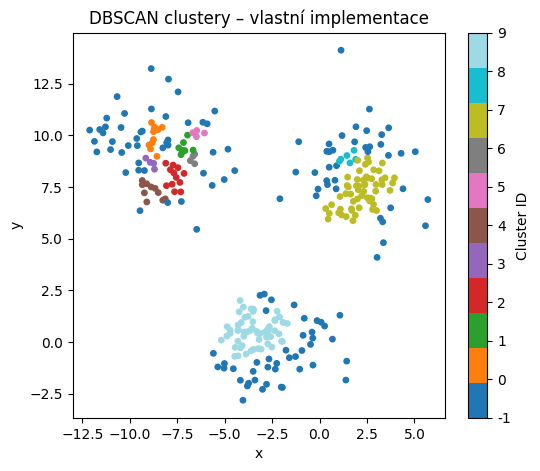

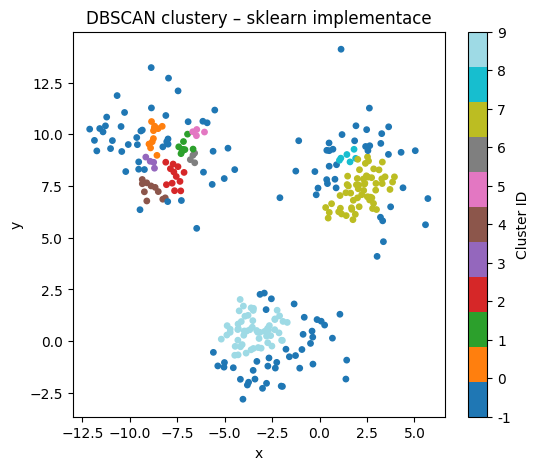

In [50]:
# připravíme diskrétní barvy tak, aby každé ID mělo vlastní barvu
unique_custom = sorted(set(labels_custom))
label_to_index_custom = {label: idx for idx, label in enumerate(unique_custom)}
colors_custom = [label_to_index_custom[label] for label in labels_custom]
cmap_custom = plt.get_cmap("tab20", len(unique_custom))

# vizualizace pro vlastní implementaci
plt.figure(figsize=(6, 5))
scatter_custom = plt.scatter(clusters_data[:, 0], clusters_data[:, 1], c=colors_custom, cmap=cmap_custom, s=15)
plt.xlabel("x")
plt.ylabel("y")
plt.title("DBSCAN clustery – vlastní implementace")
cbar_custom = plt.colorbar(scatter_custom, ticks=range(len(unique_custom)))
cbar_custom.set_label("Cluster ID")
cbar_custom.set_ticklabels(unique_custom)
plt.show()

# připravíme barvy pro sklearn implementaci
unique_sklearn = sorted(set(labels_sklearn))
label_to_index_sklearn = {label: idx for idx, label in enumerate(unique_sklearn)}
colors_sklearn = [label_to_index_sklearn[label] for label in labels_sklearn]
cmap_sklearn = plt.get_cmap("tab20", len(unique_sklearn))

# vizualizace pro sklearn implementaci
plt.figure(figsize=(6, 5))
scatter_sklearn = plt.scatter(clusters_data[:, 0], clusters_data[:, 1], c=colors_sklearn, cmap=cmap_sklearn, s=15)
plt.xlabel("x")
plt.ylabel("y")
plt.title("DBSCAN clustery – sklearn implementace")
cbar_sklearn = plt.colorbar(scatter_sklearn, ticks=range(len(unique_sklearn)))
cbar_sklearn.set_label("Cluster ID")
cbar_sklearn.set_ticklabels(unique_sklearn)
plt.show()
